### Le modele de GVAR 

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from dataclasses import dataclass

In [2]:
# ====== PARAMETRES DU MODELE ======
P = 0       # lags sur Z_i (domestique) : 1..P
P_star = 1  # lags sur Z_i* (étranger) : 0..P_star
L = 1       # lags sur X (macro) : 0..L

Z_FOLDER = "data/facteurs_systemiq/zt_am/zt_by_sector.csv"
MACRO_PATH = "data/macro_data/df_macro_stationary.csv"

OUTPUT_DIR = "data/output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

W = "data/international_TES/W_USA.csv"


In [3]:
def load_Z_single_csv(path_csv: str) -> pd.DataFrame:
    """
    Charge un seul CSV contenant :
    sector, year_quarter, z_t
    et le transforme en matrice (date × secteur)
    """
    df = pd.read_csv(path_csv)

    df["year_quarter"] = pd.to_datetime(df["year_quarter"])

    # Pivot : lignes = date, colonnes = secteur
    Z = df.pivot(
        index="year_quarter",
        columns="sector",
        values="z_t"
    )

    Z = Z.sort_index()

    return Z


In [4]:
Z = load_Z_single_csv(Z_FOLDER)
Z.head(10)


sector,construction_immo,extraction_primaire,finance,industrie,info-com,public,services,services_pro
year_quarter,,,,,,,,
2010-07-01,-3.119644,2.534563,-0.787857,-0.014226,-3.292670,-1.474542,-2.020280,-2.270018
2010-10-01,-1.660812,0.635930,-1.219453,0.355094,-0.684983,-0.687493,-1.182131,-1.597358
2011-01-01,1.428445,0.751486,-2.079168,0.798452,-0.435846,-0.815319,-1.175695,-2.016439
2011-04-01,1.800480,1.284856,-1.264702,0.586932,-0.255213,0.220045,-1.503071,-2.016439
2011-07-01,1.929722,1.030703,-1.649227,-0.020633,-0.246125,0.218599,-0.750586,-2.016439
2011-10-01,-1.656445,0.949014,-1.228758,-0.130107,-0.198410,0.643175,-0.834454,-2.045196
2012-01-01,1.672773,0.778933,-0.611153,-0.170126,-0.358526,0.083938,-0.810922,-1.409588
2012-04-01,-1.552605,-0.154775,0.600996,-0.041919,0.890062,-0.131946,0.371942,-0.410847
2012-07-01,-1.456050,-0.166745,0.900720,-0.216857,-0.450470,1.693689,0.398834,-0.410847


In [5]:
W_PATH = "data/international_TES/W_USA.csv"

W = pd.read_csv(W_PATH, index_col=0)
print(W.shape)
print(W.index[:5])
print(W.columns[:5])


(8, 8)
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie'],
      dtype='object')
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie'],
      dtype='object')


In [6]:
W

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
Construction & immobilier,0.000000,0.091805,0.044308,0.042323,0.031832,0.351652,0.319931,0.118149
Finance,0.254573,0.000000,0.063530,0.029925,0.051587,0.268942,0.186638,0.144805
Industrie,0.228690,0.016663,0.000000,0.046987,0.111211,0.295704,0.225524,0.075221
Info-com,0.058195,0.099581,0.063383,0.000000,0.023975,0.297410,0.231898,0.225556
Primaires & énergie,0.124617,0.008341,0.605653,0.008270,0.000000,0.111432,0.114349,0.027337
Public & services non-marchands,0.143104,0.108869,0.115981,0.121381,0.104516,0.000000,0.262596,0.143553
Services,0.120531,0.034140,0.404891,0.051234,0.073470,0.217926,0.000000,0.097808
Services pro,0.123352,0.096037,0.132900,0.113900,0.047629,0.213727,0.272455,0.000000


In [7]:
print(Z.columns)
print(W.index)


Index(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'],
      dtype='object', name='sector')
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object')


In [8]:
W.iloc[:8, :8]


,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
Construction & immobilier,0.000000,0.091805,0.044308,0.042323,0.031832,0.351652,0.319931,0.118149
Finance,0.254573,0.000000,0.063530,0.029925,0.051587,0.268942,0.186638,0.144805
Industrie,0.228690,0.016663,0.000000,0.046987,0.111211,0.295704,0.225524,0.075221
Info-com,0.058195,0.099581,0.063383,0.000000,0.023975,0.297410,0.231898,0.225556
Primaires & énergie,0.124617,0.008341,0.605653,0.008270,0.000000,0.111432,0.114349,0.027337
Public & services non-marchands,0.143104,0.108869,0.115981,0.121381,0.104516,0.000000,0.262596,0.143553
Services,0.120531,0.034140,0.404891,0.051234,0.073470,0.217926,0.000000,0.097808
Services pro,0.123352,0.096037,0.132900,0.113900,0.047629,0.213727,0.272455,0.000000


In [10]:
df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")
df_macro_stas.head()

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\id2415\AppData\Local\Temp\ipykernel_12616\2834272364.py:1: SyntaxWarning: invalid escape sequence '\m'
  df_macro_stas = pd.read_csv("data\macro_data\df_macro_stationary.csv")


,date,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,EU_Central_bank_Intervention_rate_policy_interest_rate_diff,...,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
0,2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,NaN,...,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
1,2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,0.0,...,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2,2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,0.0,...,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
3,2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.0,...,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
4,2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,0.0,...,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [11]:
# Convertir la date en datetime
df_macro_stas["date"] = pd.to_datetime(df_macro_stas["date"])

# Mettre date en index
df_macro_stas = df_macro_stas.set_index("date")

df_macro_stas.head()

,EU_Central_bank_Intervention_rate_policy_interest_rate,EU_GDP_Growth_Rate,JP_GDP_Growth_Rate,JP_Inflation_rate,JP_Oil_price,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,EU_Central_bank_Intervention_rate_policy_interest_rate_diff,EU_Effective_exchange_rate_hp_gap,...,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
date,,,,,,,,,,,,,,,,,,,,,
2010-01-01,1.0,0.357380,1.242027,-1.166667,77.81,0.484501,3.716667,76.674837,NaN,3.819471,...,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
2010-04-01,1.0,0.999191,1.377096,-0.933333,80.94,0.967586,3.490000,78.845036,0.0,-1.544360,...,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2010-07-01,1.0,0.478303,1.723737,-0.800000,75.44,0.771085,2.786667,76.675000,0.0,-1.790578,...,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
2010-10-01,1.0,0.612048,-0.858797,0.100000,83.37,0.525110,2.863333,87.033160,0.0,0.232728,...,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
2011-01-01,1.0,0.961402,-1.433205,-0.533333,98.52,-0.237205,3.460000,105.369424,0.0,-0.114745,...,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [13]:
# Sélectionner colonnes contenant "US_"
us_cols = [col for col in df_macro_stas.columns if col.startswith("US_")]

df_macro_us = df_macro_stas[us_cols].copy()

df_macro_us.head()

,US_GDP_Growth_Rate,US_Long_term_interest_rate,US_Oil_price,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Effective_exchange_rate_hp_gap,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_GDP_log,US_GDP_log_hp_gap,US_GDP_log_hp_gap_diff,US_House_prices_residential_hp_gap,US_House_prices_residential_hp_gap_diff,US_Long_term_interest_rate_hp_gap,US_Long_term_interest_rate_hp_gap_diff,US_Oil_price_log,US_Oil_price_log_hp_gap,US_Unemployment_rate_hp_gap,US_Unemployment_rate_hp_gap_diff
date,,,,,,,,,,,,,,,,,,
2010-01-01,0.484501,3.716667,76.674837,NaN,3.739092,NaN,0.066930,-0.724636,-0.240971,NaN,6.075059,NaN,0.604782,NaN,4.339574,-0.262272,-0.143961,NaN
2010-04-01,0.967586,3.490000,78.845036,0.0,4.981713,1.242621,-0.088895,-0.032951,0.465834,0.706805,5.401879,-0.673180,0.457614,-0.147168,4.367484,-0.237845,-0.129613,0.014349
2010-07-01,0.771085,2.786667,76.675000,0.0,3.671997,-1.309716,-0.016660,-0.259957,0.254099,-0.211735,3.589721,-1.812158,-0.166599,-0.624213,4.339576,-0.269074,-0.081841,0.047772
2010-10-01,0.525110,2.863333,87.033160,0.0,0.004494,-3.667503,0.050870,-0.644147,-0.114811,-0.368909,2.009748,-1.579973,-0.011853,0.154746,4.466289,-0.145205,0.166192,0.248033
2011-01-01,-0.237205,3.460000,105.369424,0.0,-1.191876,-1.196370,0.074041,NaN,NaN,NaN,-0.827594,-2.837341,0.661290,0.673144,4.657472,0.044092,-0.085291,-0.251483


In [14]:
macro_vars = [
    "US_GDP_Growth_Rate",
    "US_Central_bank_Intervention_rate_policy_interest_rate_diff",
    "US_Long_term_interest_rate_hp_gap_diff",
    "US_Unemployment_rate_hp_gap_diff",
    "US_House_prices_residential_hp_gap_diff",
    "US_Effective_exchange_rate_hp_gap_diff",
    "US_Equity_prices_log_hp_gap",
    "US_Oil_price_log_hp_gap"
]

In [15]:
X = df_macro_stas[macro_vars].copy()

X.head()

,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
date,,,,,,,,
2010-01-01,0.484501,NaN,NaN,NaN,NaN,NaN,0.066930,-0.262272
2010-04-01,0.967586,0.0,-0.147168,0.014349,-0.673180,1.242621,-0.088895,-0.237845
2010-07-01,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092


In [16]:
# Au lieu de chercher la colonne "date", on manipule directement l'index
X.index = pd.to_datetime(X.index)
X = X.sort_index()
X.head()

,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
date,,,,,,,,
2010-01-01,0.484501,NaN,NaN,NaN,NaN,NaN,0.066930,-0.262272
2010-04-01,0.967586,0.0,-0.147168,0.014349,-0.673180,1.242621,-0.088895,-0.237845
2010-07-01,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092


In [18]:
print("Colonnes Z :")
print(Z.columns)

print("\nIndex W :")
print(W.index)


Colonnes Z :
Index(['construction_immo', 'extraction_primaire', 'finance', 'industrie',
       'info-com', 'public', 'services', 'services_pro'],
      dtype='object', name='sector')

Index W :
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object')


In [19]:
rename_dict = {
    "construction_immo": "Construction & immobilier",
    "extraction_primaire": "Primaires & énergie",
    "finance": "Finance",
    "industrie": "Industrie",
    "info-com": "Info-com",
    "public": "Public & services non-marchands",
    "services": "Services",
    "services_pro": "Services pro"
}

Z = Z.rename(columns=rename_dict)


In [20]:
print("Colonnes Z :")
print(Z.columns)

print("\nIndex W :")
print(W.index)


Colonnes Z :
Index(['Construction & immobilier', 'Primaires & énergie', 'Finance',
       'Industrie', 'Info-com', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object', name='sector')

Index W :
Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object')


In [21]:
# Secteurs : Z doit contenir tous les secteurs de W
missing = sorted(set(W.index) - set(Z.columns))
if missing:
    raise ValueError(f"Z ne contient pas tous les secteurs de W : {missing}")

# Garder uniquement les secteurs de W, dans le même ordre
Z = Z[W.index].copy()

# Alignement sur dates communes (et dropna)
df_base = pd.concat([Z, X], axis=1).dropna()

print("Z:", Z.shape, "| X:", X.shape, "| Base alignée:", df_base.shape)


Z: (51, 8) | X: (56, 8) | Base alignée: (51, 16)


In [23]:
df_base.head()

,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,0.676582,0.0,-0.175677,0.249117,-1.732493,-1.589651,0.040477,0.153057
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,-0.022313,0.0,-0.712131,0.149890,-0.319915,0.296731,-0.143873,0.117724


In [24]:
def compute_Z_star(Z: pd.DataFrame, W: pd.DataFrame) -> pd.DataFrame:
    W2 = W.copy()
    Z_star = Z @ W2.T
    Z_star.columns = [f"{c}_star" for c in Z_star.columns]
    return Z_star

Z_star = compute_Z_star(Z, W)

# Dataset complet (Z, Z_star, X)
df_all = pd.concat([Z, Z_star, X], axis=1).dropna()
df_all.head()


,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro,Construction & immobilier_star,Finance_star,...,Services_star,Services pro_star,US_GDP_Growth_Rate,US_Central_bank_Intervention_rate_policy_interest_rate_diff,US_Long_term_interest_rate_hp_gap_diff,US_Unemployment_rate_hp_gap_diff,US_House_prices_residential_hp_gap_diff,US_Effective_exchange_rate_hp_gap_diff,US_Equity_prices_log_hp_gap,US_Oil_price_log_hp_gap
2010-07-01,-3.119644,-0.787857,-0.014226,-3.292670,2.534563,-1.474542,-2.020280,-2.270018,-1.564711,-1.865200,...,-0.934521,-1.582271,0.771085,0.0,-0.624213,0.047772,-1.812158,-1.309716,-0.016660,-0.269074
2010-10-01,-1.660812,-1.219453,0.355094,-0.684983,0.635930,-0.687493,-1.182131,-1.597358,-0.913652,-1.024763,...,-0.392467,-0.791531,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,1.428445,-2.079168,0.798452,-0.435846,0.751486,-0.815319,-1.175695,-2.016439,-1.051116,-0.290600,...,0.082451,-0.425792,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092
2011-04-01,1.800480,-1.264702,0.586932,-0.255213,1.284856,0.220045,-1.503071,-2.016439,-0.701743,0.040945,...,0.343530,-0.151725,0.676582,0.0,-0.175677,0.249117,-1.732493,-1.589651,0.040477,0.153057
2011-07-01,1.929722,-1.649227,-0.020633,-0.246125,1.030703,0.218599,-0.750586,-2.016439,-0.531434,0.162462,...,0.081461,-0.059817,-0.022313,0.0,-0.712131,0.149890,-0.319915,0.296731,-0.143873,0.117724


#################3 - stationnary + stepwise non par blocl ######

In [25]:
def build_full_design(df_all, sector, macro_cols, Pmax, Lmax):
    """
    Construit la matrice Xreg complète pour le secteur:
    const + Z*_lags (0..Pmax) + macros (k=1..K, l=0..Lmax)
    Retourne df_reg = [y | Xreg] dropna
    """
    y = df_all[sector].rename("y")
    parts = []

    # Z* lags
    zstar_col = f"{sector}_star"
    for p in range(Pmax + 1):
        parts.append(df_all[zstar_col].shift(p).rename(f"ZstarL{p}"))

    # Macros lags variable par variable
    for l in range(Lmax + 1):
        parts.append(df_all[macro_cols].shift(l).add_prefix(f"X_L{l}_"))

    Xreg = pd.concat(parts, axis=1)
    Xreg = sm.add_constant(Xreg, has_constant="add")

    df_reg = pd.concat([y, Xreg], axis=1).dropna()
    return df_reg

In [26]:
def fit_bic(df_reg, kept_cols):
    """
    Estime OLS sur les colonnes 'kept_cols' (plus y).
    kept_cols doit inclure 'const'.
    """
    y = df_reg["y"]
    X = df_reg[kept_cols]
    res = sm.OLS(y, X).fit()
    return res, res.bic

In [42]:
def backward_stepwise_bic(df_reg, candidate_cols, always_keep=("const",), min_keep=4):
    """
    Backward elimination: on part avec tous les candidats,
    et on retire 1 variable à la fois si BIC diminue.
    """
    kept = list(dict.fromkeys(list(always_keep) + list(candidate_cols)))
    kept = [c for c in kept if c in df_reg.columns]

    res_full, best_bic = fit_bic(df_reg, kept)

    improved = True
    while improved:
        improved = False
        best_drop = None
        best_drop_bic = best_bic

        # candidats supprimables
        droppable = [c for c in kept if c not in always_keep]

        if len(droppable) <= min_keep:
            break

        for c in droppable:
            trial = [k for k in kept if k != c]
            try:
                _, bic = fit_bic(df_reg, trial)
            except Exception:
                continue

            if bic < best_drop_bic:
                best_drop_bic = bic
                best_drop = c

        if best_drop is not None:
            kept.remove(best_drop)
            best_bic = best_drop_bic
            improved = True

    final_res, final_bic = fit_bic(df_reg, kept)
    return kept, final_res, final_bic

In [43]:
def stepwise_macros_then_zstar(df_all, sector, macro_cols, Pmax=4, Lmax=4, iterate=False):
    df_reg = build_full_design(df_all, sector, macro_cols, Pmax=Pmax, Lmax=Lmax)

    # Colonnes Z* et macro dans le df_reg
    zstar_cols = [c for c in df_reg.columns if c.startswith("ZstarL")]
    macro_lag_cols = [c for c in df_reg.columns if c.startswith("X_L")]

    # --- Phase A : stepwise sur macros uniquement (Z* toujours gardé au départ)
    always_keep_A = ("const",) + tuple(zstar_cols)
    kept_A, res_A, bic_A = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=macro_lag_cols,
        always_keep=always_keep_A
    )

    # --- Phase B : stepwise sur Z* uniquement (macros sélectionnées fixées)
    selected_macro_cols = [c for c in kept_A if c.startswith("X_L")]
    always_keep_B = ("const",) + tuple(selected_macro_cols)
    kept_B, res_B, bic_B = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=zstar_cols,
        always_keep=always_keep_B
    )

    if not iterate:
        return kept_B, res_B, bic_B

    # Optionnel : itération A↔B (1 tour)
    # Re-phase A en gardant les Z* sélectionnés
    zstar_selected = [c for c in kept_B if c.startswith("ZstarL")]
    always_keep_A2 = ("const",) + tuple(zstar_selected)
    kept_A2, res_A2, bic_A2 = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=macro_lag_cols,
        always_keep=always_keep_A2
    )

    selected_macro_cols2 = [c for c in kept_A2 if c.startswith("X_L")]
    always_keep_B2 = ("const",) + tuple(selected_macro_cols2)
    kept_B2, res_B2, bic_B2 = backward_stepwise_bic(
        df_reg=df_reg,
        candidate_cols=zstar_cols,
        always_keep=always_keep_B2
    )

    return kept_B2, res_B2, bic_B2

In [50]:
sector = "Construction & immobilier"
macro_cols = list(X.columns)  # ou ta liste macro réduite

kept_cols, res, bic = stepwise_macros_then_zstar(
    df_all=df_all,
    sector=sector,
    macro_cols=macro_cols,
    Pmax=4,
    Lmax=4,      # retard max macro
    iterate=True # optionnel
)

print("BIC final:", bic)
print("Nb variables gardées:", len(kept_cols))
print("Variables gardées:", kept_cols)
print(res.summary())

BIC final: 122.78588399423846
Nb variables gardées: 27
Variables gardées: ['const', 'X_L0_US_GDP_Growth_Rate', 'X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff', 'X_L0_US_Unemployment_rate_hp_gap_diff', 'X_L0_US_House_prices_residential_hp_gap_diff', 'X_L0_US_Effective_exchange_rate_hp_gap_diff', 'X_L0_US_Oil_price_log_hp_gap', 'X_L1_US_Effective_exchange_rate_hp_gap_diff', 'X_L2_US_GDP_Growth_Rate', 'X_L2_US_Central_bank_Intervention_rate_policy_interest_rate_diff', 'X_L2_US_Unemployment_rate_hp_gap_diff', 'X_L2_US_House_prices_residential_hp_gap_diff', 'X_L2_US_Effective_exchange_rate_hp_gap_diff', 'X_L3_US_GDP_Growth_Rate', 'X_L3_US_Central_bank_Intervention_rate_policy_interest_rate_diff', 'X_L3_US_Long_term_interest_rate_hp_gap_diff', 'X_L3_US_House_prices_residential_hp_gap_diff', 'X_L3_US_Effective_exchange_rate_hp_gap_diff', 'X_L4_US_GDP_Growth_Rate', 'X_L4_US_Long_term_interest_rate_hp_gap_diff', 'X_L4_US_Unemployment_rate_hp_gap_diff', 'X_L4_US_Equity_prices_

In [52]:
def run_stepwise_all_sectors(df_all, sectors, macro_cols, Pmax=4, Lmax=4, iterate=False):
    # liste de colonnes possibles (max) pour construire un coef_df stable
    max_cols = ["const"] + [f"ZstarL{p}" for p in range(Pmax+1)]
    for l in range(Lmax+1):
        max_cols += [f"X_L{l}_{c}" for c in macro_cols]

    coef_df = pd.DataFrame(index=sectors, columns=max_cols, dtype=float)
    bic_series = pd.Series(index=sectors, dtype=float)

    kept_by_sector = {}

    for s in sectors:
        kept_cols, res, bic = stepwise_macros_then_zstar(
            df_all=df_all,
            sector=s,
            macro_cols=macro_cols,
            Pmax=Pmax,
            Lmax=Lmax,
            iterate=iterate
        )
        kept_by_sector[s] = kept_cols
        bic_series.loc[s] = bic

        # remplir coef_df (les non sélectionnés restent NaN)
        for name, val in res.params.items():
            if name in coef_df.columns:
                coef_df.loc[s, name] = val

    return coef_df, bic_series, kept_by_sector

In [53]:
sectors = list(Z.columns)
macro_cols = list(X.columns)

In [55]:
coef_df, bic_series, kept_by_sector = run_stepwise_all_sectors(
    df_all=df_all,
    sectors=sectors,
    macro_cols=macro_cols,
    Pmax=4,
    Lmax=4,
    iterate=False
)

In [56]:
coef_df

,const,ZstarL0,ZstarL1,ZstarL2,ZstarL3,ZstarL4,X_L0_US_GDP_Growth_Rate,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L0_US_Long_term_interest_rate_hp_gap_diff,X_L0_US_Unemployment_rate_hp_gap_diff,...,X_L3_US_Equity_prices_log_hp_gap,X_L3_US_Oil_price_log_hp_gap,X_L4_US_GDP_Growth_Rate,X_L4_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L4_US_Long_term_interest_rate_hp_gap_diff,X_L4_US_Unemployment_rate_hp_gap_diff,X_L4_US_House_prices_residential_hp_gap_diff,X_L4_US_Effective_exchange_rate_hp_gap_diff,X_L4_US_Equity_prices_log_hp_gap,X_L4_US_Oil_price_log_hp_gap
Construction & immobilier,1.052480,-0.857941,0.782536,-0.446347,0.632372,NaN,-0.841505,-1.427574,1.024490,-1.057797,...,-5.755991,NaN,-0.449655,NaN,1.015126,-1.008343,NaN,NaN,7.093712,NaN
Finance,1.941218,5.241212,-1.861478,2.974146,-0.316623,-4.989304,1.535746,1.219236,-2.285346,0.671653,...,NaN,-5.205403,2.256220,7.763803,-1.639872,4.661984,0.367135,-0.217999,-22.129943,-0.483814
Industrie,0.427024,0.827047,0.369399,NaN,0.601773,0.388251,NaN,NaN,0.971268,0.129594,...,NaN,-0.770558,-0.209850,NaN,-0.415870,-0.383604,NaN,-0.035688,-1.681679,1.269225
Info-com,4.544015,2.285846,NaN,-1.092556,2.639696,-0.447887,NaN,NaN,-1.162054,-0.544194,...,11.252234,NaN,0.226644,NaN,NaN,1.021065,NaN,-0.257786,-12.424250,1.099114
Primaires & énergie,0.825277,-0.631191,NaN,-0.941361,0.194850,2.559156,-0.506339,-1.078237,NaN,NaN,...,1.417289,NaN,-0.468353,-5.453449,-0.555198,-0.735330,-0.190118,-0.299421,NaN,-2.786084
Public & services non-marchands,-16.748313,-0.554348,-4.102854,6.328346,-10.435666,-5.787367,5.738105,7.939781,-1.687409,7.187481,...,-15.213560,-8.694883,2.188433,13.325244,2.578319,2.539359,NaN,1.045671,32.104930,-5.314262
Services,0.334479,1.103510,-0.503381,0.850149,-0.660241,-0.547891,0.328218,0.609209,-0.392579,0.431966,...,NaN,-2.331915,NaN,NaN,-0.876381,0.191471,-0.176541,-0.042568,-4.657228,-0.683540
Services pro,-7.241392,-1.581296,0.790795,1.503026,-3.622442,2.106092,0.761983,6.647381,1.642729,2.445868,...,-12.849224,NaN,NaN,-5.800663,-0.668794,-1.478336,-0.143396,0.235152,13.464616,-1.448475


In [57]:
sectors = list(W.index)
macro_cols = list(X.columns)  # les macros que tu as retenues (K)

coef_df0 = coef_df.reindex(index=sectors).copy()
coef_df0 = coef_df0.fillna(0.0)  # <- règle : non retenu => 0

In [58]:
coef_df0

,const,ZstarL0,ZstarL1,ZstarL2,ZstarL3,ZstarL4,X_L0_US_GDP_Growth_Rate,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L0_US_Long_term_interest_rate_hp_gap_diff,X_L0_US_Unemployment_rate_hp_gap_diff,...,X_L3_US_Equity_prices_log_hp_gap,X_L3_US_Oil_price_log_hp_gap,X_L4_US_GDP_Growth_Rate,X_L4_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L4_US_Long_term_interest_rate_hp_gap_diff,X_L4_US_Unemployment_rate_hp_gap_diff,X_L4_US_House_prices_residential_hp_gap_diff,X_L4_US_Effective_exchange_rate_hp_gap_diff,X_L4_US_Equity_prices_log_hp_gap,X_L4_US_Oil_price_log_hp_gap
Construction & immobilier,1.052480,-0.857941,0.782536,-0.446347,0.632372,0.000000,-0.841505,-1.427574,1.024490,-1.057797,...,-5.755991,0.000000,-0.449655,0.000000,1.015126,-1.008343,0.000000,0.000000,7.093712,0.000000
Finance,1.941218,5.241212,-1.861478,2.974146,-0.316623,-4.989304,1.535746,1.219236,-2.285346,0.671653,...,0.000000,-5.205403,2.256220,7.763803,-1.639872,4.661984,0.367135,-0.217999,-22.129943,-0.483814
Industrie,0.427024,0.827047,0.369399,0.000000,0.601773,0.388251,0.000000,0.000000,0.971268,0.129594,...,0.000000,-0.770558,-0.209850,0.000000,-0.415870,-0.383604,0.000000,-0.035688,-1.681679,1.269225
Info-com,4.544015,2.285846,0.000000,-1.092556,2.639696,-0.447887,0.000000,0.000000,-1.162054,-0.544194,...,11.252234,0.000000,0.226644,0.000000,0.000000,1.021065,0.000000,-0.257786,-12.424250,1.099114
Primaires & énergie,0.825277,-0.631191,0.000000,-0.941361,0.194850,2.559156,-0.506339,-1.078237,0.000000,0.000000,...,1.417289,0.000000,-0.468353,-5.453449,-0.555198,-0.735330,-0.190118,-0.299421,0.000000,-2.786084
Public & services non-marchands,-16.748313,-0.554348,-4.102854,6.328346,-10.435666,-5.787367,5.738105,7.939781,-1.687409,7.187481,...,-15.213560,-8.694883,2.188433,13.325244,2.578319,2.539359,0.000000,1.045671,32.104930,-5.314262
Services,0.334479,1.103510,-0.503381,0.850149,-0.660241,-0.547891,0.328218,0.609209,-0.392579,0.431966,...,0.000000,-2.331915,0.000000,0.000000,-0.876381,0.191471,-0.176541,-0.042568,-4.657228,-0.683540
Services pro,-7.241392,-1.581296,0.790795,1.503026,-3.622442,2.106092,0.761983,6.647381,1.642729,2.445868,...,-12.849224,0.000000,0.000000,-5.800663,-0.668794,-1.478336,-0.143396,0.235152,13.464616,-1.448475


In [62]:
def build_B_matrices_from_coef(W: pd.DataFrame, coef_df0: pd.DataFrame, P_star: int) -> dict:
    N = W.shape[0]
    sectors = list(W.index)

    W2 = W.copy()

    B = {}
    for p in range(0, P_star + 1):
        col = f"ZstarL{p}"
        beta = coef_df0[col].reindex(sectors).values.reshape(N, 1) if col in coef_df0.columns else np.zeros((N,1))
        Bp = beta * W2.values  # diag(beta) @ W  (broadcasting)
        B[p] = pd.DataFrame(Bp, index=sectors, columns=sectors)

    return B

B = build_B_matrices_from_coef(W, coef_df0, P_star=4)
print("B0 shape:", B[0].shape)

B0 shape: (8, 8)


In [64]:
def build_Gamma_matrices_from_coef(coef_df0: pd.DataFrame, sectors: list, macro_cols: list, L: int) -> dict:
    Gamma = {}
    for l in range(0, L + 1):
        cols_l = [f"X_L{l}_{m}" for m in macro_cols]
        # si une colonne manque (par ex. jamais créée), on la crée à 0
        for c in cols_l:
            if c not in coef_df0.columns:
                coef_df0[c] = 0.0

        Gammal = coef_df0.loc[sectors, cols_l].values  # (N×K)
        Gamma[l] = pd.DataFrame(Gammal, index=sectors, columns=macro_cols)

    return Gamma

Gamma = build_Gamma_matrices_from_coef(coef_df0, sectors, macro_cols, L=4)
print("Gamma0 shape:", Gamma[0].shape)

Gamma0 shape: (8, 8)


In [65]:
Gamma

{0:                                  US_GDP_Growth_Rate  \
 Construction & immobilier                 -0.841505   
 Finance                                    1.535746   
 Industrie                                  0.000000   
 Info-com                                   0.000000   
 Primaires & énergie                       -0.506339   
 Public & services non-marchands            5.738105   
 Services                                   0.328218   
 Services pro                               0.761983   
 
                                  US_Central_bank_Intervention_rate_policy_interest_rate_diff  \
 Construction & immobilier                                                -1.427574             
 Finance                                                                   1.219236             
 Industrie                                                                 0.000000             
 Info-com                                                                  0.000000             
 Prima

In [66]:
def build_reduced_form(B: dict, Gamma: dict, coef_df0: pd.DataFrame, sectors: list, P_star: int, L: int):
    N = len(sectors)

    # c (constante empilée)
    if "const" in coef_df0.columns:
        c = coef_df0.loc[sectors, "const"].values.reshape(N, 1)
    else:
        c = np.zeros((N, 1))

    # G = I - B0
    I = np.eye(N)
    G = I - B[0].values

    # inverse
    Ginv = np.linalg.inv(G)

    # mu, Fp, tildeGamma
    mu = Ginv @ c

    F = {}
    for p in range(1, P_star + 1):
        F[p] = pd.DataFrame(Ginv @ B[p].values, index=sectors, columns=sectors)

    tildeGamma = {}
    for l in range(0, L + 1):
        tildeGamma[l] = pd.DataFrame(Ginv @ Gamma[l].values, index=sectors, columns=Gamma[l].columns)

    return (
        pd.DataFrame(G, index=sectors, columns=sectors),
        mu,
        F,
        tildeGamma
    )

G_mat, mu, F, tildeGamma = build_reduced_form(B, Gamma, coef_df0, sectors, P_star=P_star, L=L)

print("G shape:", G_mat.shape)
print("mu shape:", mu.shape)
print("F[1] shape:", F[1].shape if P_star >= 1 else None)
print("tildeGamma[0] shape:", tildeGamma[0].shape)

G shape: (8, 8)
mu shape: (8, 1)
F[1] shape: (8, 8)
tildeGamma[0] shape: (8, 8)


In [67]:
detG = np.linalg.det(G_mat.values)
condG = np.linalg.cond(G_mat.values)
print("det(G) =", detG)
print("cond(G) =", condG)

det(G) = 1.424191071146065
cond(G) = 6.177202255173282


In [87]:
import numpy as np
import pandas as pd

sectors = list(W.index)

# (1) récupérer c (constantes) sous forme vecteur (N,1)
c = coef_df0.loc[sectors, "const"].values.reshape(-1, 1) if "const" in coef_df0.columns else np.zeros((len(sectors), 1))

# (2) construire G = I - B0
N = len(sectors)
G = np.eye(N) - B[0].values

# (3) inverser
Ginv = np.linalg.inv(G)

# (4) mu
mu = Ginv @ c   # (N,1)

# (5) F_p
P_star = max(B.keys())  # si B contient p=0..P_star
F = {}
for p in range(1, P_star + 1):
    F[p] = pd.DataFrame(Ginv @ B[p].values, index=sectors, columns=sectors)

# (6) tildeGamma_l
L = max(Gamma.keys())   # si Gamma contient l=0..L
tildeGamma = {}
for l in range(0, L + 1):
    tildeGamma[l] = pd.DataFrame(Ginv @ Gamma[l].values, index=sectors, columns=Gamma[l].columns)

print("P_star =", P_star, "| L =", L)
print("mu:", mu.shape, "| F[1]:" , (F[1].shape if P_star>=1 else None), "| tildeGamma[0]:", tildeGamma[0].shape)
print("det(G) =", np.linalg.det(G), "| cond(G) =", np.linalg.cond(G))

P_star = 4 | L = 4
mu: (8, 1) | F[1]: (8, 8) | tildeGamma[0]: (8, 8)
det(G) = 1.424191071146065 | cond(G) = 6.177202255173282


In [88]:
# Z doit déjà contenir les secteurs (même ordre que W.index)
Z_hist = Z[sectors].dropna().copy()

# Conditions initiales: dernières P_star lignes
Z_init = Z_hist.iloc[-P_star:].copy()

print("Z_hist last date:", Z_hist.index[-1])
print("Z_init shape:", Z_init.shape)

Z_hist last date: 2023-01-01 00:00:00
Z_init shape: (4, 8)


In [ ]:
# X_scenario : index = dates, colonnes = macros (K)
X_scenario = X_scenario
X_scenario.index = pd.to_datetime(X_scenario.index)

last_hist_date = pd.to_datetime(Z_hist.index[-1])

# Garder uniquement les dates futures
X_scenario_future = X_scenario[X_scenario.index >= last_hist_date].copy()

print("Last hist:", last_hist_date)
print("Scenario start:", X_scenario_future.index[0] if len(X_scenario_future)>0 else None)
print("Scenario shape:", X_scenario_future.shape)

Last hist: 2023-01-01 00:00:00
Scenario start: 2023-01-01 00:00:00
Scenario shape: (109, 9)


In [103]:
print("---- CHECK DIMENSIONS ----")
print("P_star =", P_star)
print("L =", L)

print("Z_init shape:", Z_init.shape)
print("Z_init columns:", Z_init.columns)

print("F keys:", F.keys())
print("F[1] shape:", F[1].shape if P_star >= 1 else None)

print("tildeGamma keys:", tildeGamma.keys())
print("tildeGamma[0] shape:", tildeGamma[0].shape)

print("X_future shape:", X_scenario_future.shape)
print("X_future columns:", X_scenario_future.columns)

print("Nb sectors:", len(Z_init.columns))
print("Nb macros:", len(X_scenario_future.columns))

---- CHECK DIMENSIONS ----
P_star = 4
L = 4
Z_init shape: (4, 8)
Z_init columns: Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object', name='sector')
F keys: dict_keys([1, 2, 3, 4])
F[1] shape: (8, 8)
tildeGamma keys: dict_keys([0, 1, 2, 3, 4])
tildeGamma[0] shape: (8, 8)
X_future shape: (109, 9)
X_future columns: Index(['US_Central_bank_Intervention_rate_policy_interest_rate',
       'US_Effective_exchange_rate', 'US_Equity_prices', 'US_GDP_Growth_Rate',
       'US_House_prices_residential', 'US_Inflation_rate',
       'US_Long_term_interest_rate', 'US_Oil_price', 'US_Unemployment_rate'],
      dtype='object')
Nb sectors: 8
Nb macros: 9


In [102]:
X_scenario_future.columns

Index(['US_Central_bank_Intervention_rate_policy_interest_rate',
       'US_Effective_exchange_rate', 'US_Equity_prices', 'US_GDP_Growth_Rate',
       'US_House_prices_residential', 'US_Inflation_rate',
       'US_Long_term_interest_rate', 'US_Oil_price', 'US_Unemployment_rate'],
      dtype='object')

In [104]:
macro_cols

['US_GDP_Growth_Rate',
 'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
 'US_Long_term_interest_rate_hp_gap_diff',
 'US_Unemployment_rate_hp_gap_diff',
 'US_House_prices_residential_hp_gap_diff',
 'US_Effective_exchange_rate_hp_gap_diff',
 'US_Equity_prices_log_hp_gap',
 'US_Oil_price_log_hp_gap']

In [99]:
def project_gvar(Z_init: pd.DataFrame,
                 X_future: pd.DataFrame,
                 mu: np.ndarray,
                 F: dict,
                 tildeGamma: dict,
                 P_star: int,
                 L: int) -> pd.DataFrame:
    """
    Z_init: (P_star x N) dernières valeurs observées, colonnes=secteurs
    X_future: (H x K) scénario macro futur, index=dates futures
    mu: (N,1)
    """
    sectors = list(Z_init.columns)
    N = len(sectors)
    H = len(X_future)
    macro_cols = list(X_future.columns)

    # buffer lags: Z_{t-1}, Z_{t-2}, ... en vecteurs (N,1)
    lag_buffer = [Z_init.iloc[-p].values.reshape(N, 1) for p in range(1, P_star+1)]

    out = []

    for h in range(H):
        z_new = mu.copy()

        # dynamique via F_p
        for p in range(1, P_star+1):
            z_new += F[p].values @ lag_buffer[p-1]

        # macros
        for l in range(0, L+1):
            if h - l >= 0:
                x_vec = X_future.iloc[h-l].values.reshape(-1, 1)  # (K,1)
                z_new += tildeGamma[l].values @ x_vec

        out.append(z_new.ravel())

        # update buffer
        lag_buffer = [z_new] + lag_buffer[:-1]

    Z_proj = pd.DataFrame(out, index=X_future.index, columns=sectors)
    return Z_proj

In [100]:
Z_proj_baseline = project_gvar(
    Z_init=Z_init,
    X_future=X_scenario_future,
    mu=mu,
    F=F,
    tildeGamma=tildeGamma,
    P_star=P_star,
    L=L
)

print("Z_proj_baseline:", Z_proj_baseline.shape)
Z_proj_baseline.head()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 9 is different from 8)

################# fin 3 

##################################################

In [38]:
def build_design_sector(df_all, sector, P_star, L, macro_cols):
    
    # Variable dépendante
    y = df_all[sector]
    
    X_parts = []
    
    # Z_star lags
    for p in range(0, P_star + 1):
        X_parts.append(df_all[f"{sector}_star"].shift(p).rename(f"ZstarL{p}"))
    
    # Macros lags
    for l in range(0, L + 1):
        X_parts.append(
            df_all[macro_cols].shift(l).add_prefix(f"X_L{l}_")
        )
    
    Xreg = pd.concat(X_parts, axis=1)
    Xreg = sm.add_constant(Xreg, has_constant="add")
    
    df_reg = pd.concat([y.rename("y"), Xreg], axis=1).dropna()
    
    return df_reg

In [39]:
X.columns

Index(['US_GDP_Growth_Rate',
       'US_Central_bank_Intervention_rate_policy_interest_rate_diff',
       'US_Long_term_interest_rate_hp_gap_diff',
       'US_Unemployment_rate_hp_gap_diff',
       'US_House_prices_residential_hp_gap_diff',
       'US_Effective_exchange_rate_hp_gap_diff', 'US_Equity_prices_log_hp_gap',
       'US_Oil_price_log_hp_gap'],
      dtype='object')

In [45]:
macro_cols = list(X.columns)

sector = "Finance"

df_reg = build_design_sector(
    df_all=df_all,
    sector=sector,
    P_star=1,
    L=0,
    macro_cols=macro_cols
)

df_reg.head()

,y,const,ZstarL0,ZstarL1,X_L0_US_GDP_Growth_Rate,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate_diff,X_L0_US_Long_term_interest_rate_hp_gap_diff,X_L0_US_Unemployment_rate_hp_gap_diff,X_L0_US_House_prices_residential_hp_gap_diff,X_L0_US_Effective_exchange_rate_hp_gap_diff,X_L0_US_Equity_prices_log_hp_gap,X_L0_US_Oil_price_log_hp_gap
2010-10-01,-1.219453,1.0,-1.024763,-1.865200,0.525110,0.0,0.154746,0.248033,-1.579973,-3.667503,0.050870,-0.145205
2011-01-01,-2.079168,1.0,-0.290600,-1.024763,-0.237205,0.0,0.673144,-0.251483,-2.837341,-1.196370,0.074041,0.044092
2011-04-01,-1.264702,1.0,0.040945,-0.290600,0.676582,0.0,-0.175677,0.249117,-1.732493,-1.589651,0.040477,0.153057
2011-07-01,-1.649227,1.0,0.162462,0.040945,-0.022313,0.0,-0.712131,0.149890,-0.319915,0.296731,-0.143873,0.117724
2011-10-01,-1.228758,1.0,-0.665851,0.162462,1.123049,0.0,-0.313187,-0.149268,-0.344489,2.121182,-0.067994,0.092499


In [48]:
res = sm.OLS(df_reg["y"], df_reg.drop(columns="y")).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     7.079
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           3.22e-06
Time:                        18:32:30   Log-Likelihood:                -44.679
No. Observations:                  50   AIC:                             111.4
Df Residuals:                      39   BIC:                             132.4
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [43]:
def select_lags_sector(df_all, sector, macro_cols,
                       P_grid=(0,1,2,3),
                       L_grid=(0,1,2,3)):
    
    results = []
    
    for P_star in P_grid:
        for L in L_grid:
            
            try:
                df_reg = build_design_sector(df_all, sector, P_star, L, macro_cols)
                res = sm.OLS(df_reg["y"], df_reg.drop(columns="y")).fit()
                
                results.append({
                    "P_star": P_star,
                    "L": L,
                    "BIC": res.bic
                })
            except:
                continue
    
    return pd.DataFrame(results).sort_values("BIC")

In [44]:
select_lags_sector(
    df_all,
    sector="Finance",
    macro_cols=macro_cols
)

,P_star,L,BIC
4,1,0,132.390288
8,2,0,134.316682
12,3,0,135.008991
0,0,0,136.965401
1,0,1,156.893464
5,1,1,160.781912
9,2,1,161.202123
13,3,1,162.273932
2,0,2,169.716843
6,1,2,173.046140


##################################################

In [38]:
def lag_series(s: pd.Series, max_lag: int, prefix: str) -> pd.DataFrame:
    """Crée les lags 0..max_lag d'une série."""
    out = []
    for l in range(0, max_lag + 1):
        out.append(s.shift(l).rename(f"{prefix}L{l}"))
    return pd.concat(out, axis=1)

def lag_dataframe(df: pd.DataFrame, max_lag: int, prefix: str) -> pd.DataFrame:
    """Crée les lags 0..max_lag de toutes les colonnes d'un DF."""
    out = []
    for l in range(0, max_lag + 1):
        tmp = df.shift(l).add_prefix(f"{prefix}L{l}_")
        out.append(tmp)
    return pd.concat(out, axis=1)


#Estimation OLS secteur par secteur 

In [40]:
def estimate_sector_varx(
    df_all: pd.DataFrame,
    sector: str,
    macro_cols: list[str],
    P: int,
    P_star: int,
    L: int
):
    """
    Estime: Z_i(t) ~ const + lags(Z_i, 1..P) + lags(Z_i*, 0..P_star) + lags(X, 0..L)
    """
    y = df_all[sector]

    # --- Retards domestiques (1..P)
    X_dom = []
    for p in range(1, P + 1):
        X_dom.append(df_all[sector].shift(p).rename(f"ZL{p}"))

    X_dom = pd.concat(X_dom, axis=1) if X_dom else None

    # --- Retards étrangers (0..P_star)
    star_col = f"{sector}_star"
    X_star = lag_series(df_all[star_col], P_star, prefix="Zstar")  # L0..LP_star

    # --- Retards macro (0..L)
    X_macro = lag_dataframe(df_all[macro_cols], L, prefix="X_") if macro_cols else None

    # --- Assemblage régressions
    X_parts = []
    if X_dom is not None:
        X_parts.append(X_dom)
    X_parts.append(X_star)
    if X_macro is not None:
        X_parts.append(X_macro)

    Xreg = pd.concat(X_parts, axis=1)
    data = pd.concat([y.rename("y"), Xreg], axis=1).dropna()

    y2 = data["y"]
    X2 = sm.add_constant(data.drop(columns=["y"]))
    model = sm.OLS(y2, X2).fit()

    return model

macro_cols = list(X.columns)

models = {}
residuals = {}
coefs = {}

for s in W.index:
    m = estimate_sector_varx(df_all, sector=s, macro_cols=macro_cols, P=P, P_star=P_star, L=L)
    models[s] = m
    residuals[s] = m.resid
    coefs[s] = m.params

# Exemple d'output
first_sector = W.index[0]
print(first_sector)
print(models[first_sector].summary())


Construction & immobilier
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     1.080
Date:                Fri, 20 Feb 2026   Prob (F-statistic):              0.417
Time:                        14:45:32   Log-Likelihood:                -56.581
No. Observations:                  50   AIC:                             155.2
Df Residuals:                      29   BIC:                             195.3
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

In [41]:
coef_df = pd.DataFrame(coefs).T  # index=secteurs, colonnes=params
coef_df.to_csv(os.path.join(OUTPUT_DIR, "gvar_step1_coef_all.csv"))

resid_df = pd.DataFrame(residuals).dropna()
resid_df.to_csv(os.path.join(OUTPUT_DIR, "gvar_step1_residuals.csv"))

print("Saved:")
print(" -", os.path.join(OUTPUT_DIR, "gvar_step1_coef_all.csv"))
print(" -", os.path.join(OUTPUT_DIR, "gvar_step1_residuals.csv"))

coef_df.head()


Saved:
 - data/output\gvar_step1_coef_all.csv
 - data/output\gvar_step1_residuals.csv


,const,ZstarL0,ZstarL1,X_L0_US_Central_bank_Intervention_rate_policy_interest_rate,X_L0_US_Effective_exchange_rate,X_L0_US_Equity_prices,X_L0_US_GDP_Growth_Rate,X_L0_US_House_prices_residential,X_L0_US_Inflation_rate,X_L0_US_Long_term_interest_rate,...,X_L0_US_Unemployment_rate,X_L1_US_Central_bank_Intervention_rate_policy_interest_rate,X_L1_US_Effective_exchange_rate,X_L1_US_Equity_prices,X_L1_US_GDP_Growth_Rate,X_L1_US_House_prices_residential,X_L1_US_Inflation_rate,X_L1_US_Long_term_interest_rate,X_L1_US_Oil_price,X_L1_US_Unemployment_rate
Construction & immobilier,-1.634401,-0.418786,0.466567,-0.863210,-0.040446,0.023194,0.012176,-0.013994,0.512673,0.499599,...,0.194652,0.657733,0.099963,0.020229,0.052261,-0.092695,-0.026669,0.656588,0.013466,0.170478
Finance,11.614532,0.648238,0.169937,2.196593,0.005354,0.004929,-0.076189,-0.024582,-0.169540,0.427655,...,0.216194,-1.650595,-0.052180,0.059256,-0.020005,-0.092943,-0.021109,-1.145893,0.012330,-0.030366
Industrie,-3.251662,0.866543,0.324345,-1.090398,-0.002508,0.008406,-0.057178,-0.198258,-0.046634,0.672695,...,-0.032380,0.563748,0.030221,-0.009143,-0.004230,0.206848,0.036634,-0.314100,0.003676,0.111300
Info-com,5.070416,-0.009650,0.591865,0.986693,-0.047682,-0.004179,0.362046,-0.190479,-0.043376,0.157729,...,0.751001,-0.968540,0.048659,0.060933,0.073143,0.084791,-0.105863,-0.404091,0.027866,-0.416413
Primaires & énergie,9.969597,0.810540,0.562820,0.210929,-0.018003,-0.013714,0.192660,-0.379683,0.509337,-0.627363,...,0.283745,0.676223,-0.035984,0.004010,0.162814,0.367582,0.023386,-0.343602,-0.021228,-0.107841


# Construction du GVAR 

In [42]:
def build_B_matrices(W: pd.DataFrame, coef_df: pd.DataFrame, P_star: int):
    """
    Construit B_p pour p=0..P_star à partir des coefficients beta_i,p = coef['ZstarLp'].
    """
    N = W.shape[0]
    sectors = list(W.index)

    # sécurité : diagonale W nulle
    W2 = W.copy()
    np.fill_diagonal(W2.values, 0.0)

    B = {}
    for p in range(0, P_star + 1):
        # vecteur beta_{i,p} pour tous i
        beta_name = f"ZstarL{p}"
        if beta_name not in coef_df.columns:
            raise ValueError(f"Colonne manquante dans coef_df: {beta_name}")

        beta_vec = coef_df.loc[sectors, beta_name].values.reshape(-1, 1)  # (N,1)

        # B_p = diag(beta_vec) * W
        Bp = (beta_vec * W2.values)  # broadcasting ligne i
        np.fill_diagonal(Bp, 0.0)    # imposer (i,i)=0
        B[p] = pd.DataFrame(Bp, index=sectors, columns=sectors)

    return B

B = build_B_matrices(W, coef_df, P_star=P_star)

# Vérifier dimensions
print("B0 shape:", B[0].shape)

# Matrice G = I - B0 (utile si tu as un contemporain)
I = np.eye(W.shape[0])
G = pd.DataFrame(I - B[0].values, index=W.index, columns=W.columns)

# Vérifier inversibilité numérique (conditionnement)
cond_G = np.linalg.cond(G.values)
det_G = np.linalg.det(G.values)

print("det(G) =", det_G)
print("cond(G) =", cond_G)


B0 shape: (8, 8)
det(G) = 0.7390816524701281
cond(G) = 4.0648011653389915


In [45]:
def build_Gamma_matrices(coef_df, sectors, macro_cols, L):

    Gamma = {}

    for l in range(0, L+1):

        # noms exacts des colonnes pour ce lag
        cols_l = [f"X_L{l}_{mc}" for mc in macro_cols]

        # vérifier qu'elles existent
        for c in cols_l:
            if c not in coef_df.columns:
                raise ValueError(f"Colonne manquante : {c}")

        Gl = coef_df.loc[sectors, cols_l].values  # matrice m x K

        Gamma[l] = pd.DataFrame(
            Gl,
            index=sectors,
            columns=macro_cols
        )

    return Gamma

In [46]:
coef_df.columns

Index(['const', 'ZstarL0', 'ZstarL1',
       'X_L0_US_Central_bank_Intervention_rate_policy_interest_rate',
       'X_L0_US_Effective_exchange_rate', 'X_L0_US_Equity_prices',
       'X_L0_US_GDP_Growth_Rate', 'X_L0_US_House_prices_residential',
       'X_L0_US_Inflation_rate', 'X_L0_US_Long_term_interest_rate',
       'X_L0_US_Oil_price', 'X_L0_US_Unemployment_rate',
       'X_L1_US_Central_bank_Intervention_rate_policy_interest_rate',
       'X_L1_US_Effective_exchange_rate', 'X_L1_US_Equity_prices',
       'X_L1_US_GDP_Growth_Rate', 'X_L1_US_House_prices_residential',
       'X_L1_US_Inflation_rate', 'X_L1_US_Long_term_interest_rate',
       'X_L1_US_Oil_price', 'X_L1_US_Unemployment_rate'],
      dtype='object')

In [47]:
macro_cols = [
    'US_Central_bank_Intervention_rate_policy_interest_rate',
    'US_Effective_exchange_rate',
    'US_Equity_prices',
    'US_GDP_Growth_Rate',
    'US_House_prices_residential',
    'US_Inflation_rate',
    'US_Long_term_interest_rate',
    'US_Oil_price',
    'US_Unemployment_rate'
]

In [49]:
sectors = list(W.index)

In [50]:
Gamma = build_Gamma_matrices(
    coef_df=coef_df,
    sectors=sectors,
    macro_cols=macro_cols,
    L=1
)

In [54]:
Gamma

{0:                                  US_Central_bank_Intervention_rate_policy_interest_rate  \
 Construction & immobilier                                                -0.863210        
 Finance                                                                   2.196593        
 Industrie                                                                -1.090398        
 Info-com                                                                  0.986693        
 Primaires & énergie                                                       0.210929        
 Public & services non-marchands                                           1.761028        
 Services                                                                  1.062897        
 Services pro                                                             -0.516194        
 
                                  US_Effective_exchange_rate  US_Equity_prices  \
 Construction & immobilier                         -0.040446          0.023194   
 Fi

In [69]:
G_inv = np.linalg.inv(G_mat.values)

####################

In [73]:
P1 = 4
L=4

In [74]:
F = {}

for p in range(1, P1+1):
    F[p] = pd.DataFrame(
        G_inv @ B[p].values,
        index=sectors,
        columns=sectors
    )

In [75]:
tildeGamma = {}

for l in range(0, L+1):
    tildeGamma[l] = pd.DataFrame(
        G_inv @ Gamma[l].values,
        index=sectors,
        columns=macro_cols
    )

In [76]:
alpha = coef_df.loc[sectors, "const"].values.reshape(-1,1)

mu = G_inv @ alpha

In [77]:
eigvals = np.linalg.eigvals(F[1].values)
print(np.abs(eigvals).max())

0.7414510962678487


un modele stable donc ! 

## PRojections 

In [78]:
import pandas as pd
import numpy as np

def project_gvar(Z_init, X_scenario, mu, F, tildeGamma, P_star, L):
    """
    Z_init: DataFrame (P_star x N) dernières valeurs observées, colonnes=secteurs
    X_scenario: DataFrame (H x K) index=dates, colonnes=macro_cols (sans 'date' en colonne)
    mu: array (N,1)
    F: dict p-> DataFrame (N x N), p=1..P_star
    tildeGamma: dict l-> DataFrame (N x K), l=0..L
    """
    sectors = list(Z_init.columns)
    N = len(sectors)
    H = len(X_scenario)

    # On garde un historique avec les bonnes colonnes
    Z_lags = Z_init.copy()

    projections = []

    for h in range(H):
        z_new = mu.copy()

        # dynamique sectorielle
        for p in range(1, P_star + 1):
            z_lag = Z_lags.iloc[-p][sectors].values.reshape(N, 1)
            z_new += F[p].values @ z_lag

        # bloc macro
        for l in range(0, L + 1):
            if h - l >= 0:
                x_val = X_scenario.iloc[h - l].values.reshape(-1, 1)
                z_new += tildeGamma[l].values @ x_val

        # stocker projection
        projections.append(z_new.ravel())

        # AJOUTER UNE LIGNE avec les MÊMES colonnes
        new_row = pd.DataFrame([z_new.ravel()], columns=sectors, index=[X_scenario.index[h]])
        Z_lags = pd.concat([Z_lags, new_row], axis=0)

    Z_proj = pd.DataFrame(projections, index=X_scenario.index, columns=sectors)
    return Z_proj

In [79]:
Z_hist = Z[sectors].dropna()

Z_init = Z_hist.iloc[-P_star:].copy()

In [80]:
Z_init

sector,Construction & immobilier,Finance,Industrie,Info-com,Primaires & énergie,Public & services non-marchands,Services,Services pro
year_quarter,,,,,,,,
2023-01-01,1.609668,-1.491594,-1.988983,-2.187928,-0.579247,-2.003627,-1.354102,1.05947


In [81]:
print("Nombre secteurs dans W :", len(W.index))
print("Shape F[1] :", F[1].shape)
print("Colonnes Z_init :", len(Z_init.columns))
print("Z_init columns :", Z_init.columns)

Nombre secteurs dans W : 8
Shape F[1] : (8, 8)
Colonnes Z_init : 8
Z_init columns : Index(['Construction & immobilier', 'Finance', 'Industrie', 'Info-com',
       'Primaires & énergie', 'Public & services non-marchands', 'Services',
       'Services pro'],
      dtype='object', name='sector')


In [93]:
X_scenario=pd.read_csv("data/ngfs_data/ngfs_us.csv")

In [94]:
X_scenario = X_scenario.set_index("date")

In [95]:
X_scenario.index = pd.to_datetime(X_scenario.index)

In [85]:
last_hist_date = Z_hist.index[-1]

X_scenario = X_scenario[X_scenario.index > last_hist_date]

In [86]:
Z_proj = project_gvar(
    Z_init=Z_init,
    X_scenario=X_scenario,
    mu=mu,
    F=F,
    tildeGamma=tildeGamma,
    P_star=P_star,
    L=L
)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 9 is different from 8)

In [90]:
print(X_scenario.columns)

Index(['US_Central_bank_Intervention_rate_policy_interest_rate',
       'US_Effective_exchange_rate', 'US_Equity_prices', 'US_GDP_Growth_Rate',
       'US_House_prices_residential', 'US_Inflation_rate',
       'US_Long_term_interest_rate', 'US_Oil_price', 'US_Unemployment_rate'],
      dtype='object')


In [91]:
Z_hist = Z_hist.copy()
Z_proj = Z_proj.copy()

Z_hist.index = pd.to_datetime(Z_hist.index)
Z_proj.index = pd.to_datetime(Z_proj.index)

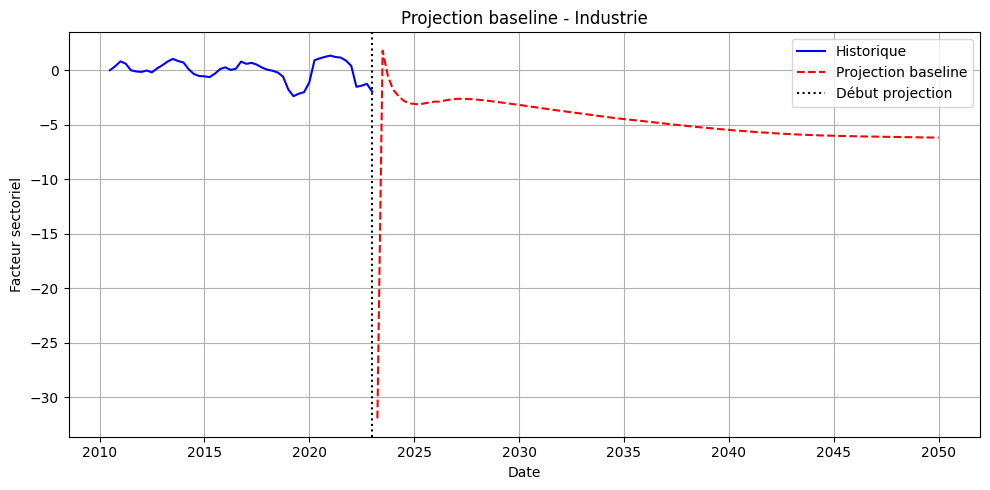

In [92]:
import matplotlib.pyplot as plt

sector_to_plot = "Industrie"  # adapte si besoin

# concat historique + projection
Z_full = pd.concat([Z_hist[sector_to_plot], Z_proj[sector_to_plot]])

plt.figure(figsize=(10,5))

# Historique
plt.plot(Z_hist.index,
         Z_hist[sector_to_plot],
         label="Historique",
         color="blue")

# Projection
plt.plot(Z_proj.index,
         Z_proj[sector_to_plot],
         label="Projection baseline",
         linestyle="--",
         color="red")

plt.axvline(Z_hist.index[-1], color="black", linestyle=":", label="Début projection")

plt.title(f"Projection baseline - {sector_to_plot}")
plt.xlabel("Date")
plt.ylabel("Facteur sectoriel")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [85]:
print(Z_hist.index[-1])
print(X_scenario.index[0])

2023-01-01 00:00:00
2022-01-01
